In [31]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as geopd
import matplotlib.pyplot as plt
import subprocess

## Config

In [32]:
DIR = "/home/dy23a.fsu/st/datasets/raw"
DIR = os.path.join(DIR, "SF")
TAXI_FILE = Path(DIR) / "sf_taxi_2023.csv"
BIKE_DIR = Path(DIR) / "bike"

FLOW_MODE = "arrival"  # arrival -> dropoff/end ; departure -> pickup/start
assert FLOW_MODE in {"arrival", "departure"}

NHOODS_PATH = "./SF Analysis Neighborhoods.geojson"

OUT_DIR = Path(DIR)

# SF has only two mobilities -- taxi (SFMTA) and bike (Bay Wheels) -- and BOTH
# are GPS-based, so every endpoint is spatially joined to an analysis-
# neighborhood polygon (like DC). Unlike DC's hour-rounded taxi, SF taxi
# timestamps keep full second precision, so the dataset stays on a 15-min grid
# (matching NYC / Chicago).

# Optional sub-region filter (analogous to NYC borough / Chicago areas). Set to
# a list of neighborhood names (e.g. ["Mission", "South of Market"]) to keep
# only those; leave as None / "all" to keep every neighborhood.
TARGET_NHOODS = None
TARGET_TAG = "subset"

In [33]:
YEAR = 2023
FREQ = "15min"
TIME_START = pd.Timestamp(f"{YEAR}-01-01 00:00:00")
TIME_END = pd.Timestamp(f"{YEAR + 1}-01-01 00:00:00")
STEPS = pd.date_range(TIME_START, TIME_END, freq=FREQ, inclusive="left")
T = len(STEPS)
FREQ_TAG = FREQ
print(f"YEAR={YEAR}, FREQ={FREQ}, T={T} steps, FLOW_MODE={FLOW_MODE}")

YEAR=2023, FREQ=15min, T=35040 steps, FLOW_MODE=arrival


## Shapefile and helpers

Region order follows the shapefile (sorted by `nhood`); all output `(N, T)`
arrays use this same order. Neighborhoods are identified by `nhood` (e.g.
`Mission`, `South of Market`).

In [34]:
nhoods = geopd.read_file(NHOODS_PATH).to_crs("EPSG:4326")
nhoods = nhoods.sort_values("nhood").reset_index(drop=True)
nhoods["region_idx"] = np.arange(len(nhoods), dtype=np.int32)
nhoods_for_join = nhoods[["region_idx", "geometry"]]
N = len(nhoods)
bounds = nhoods.total_bounds
name_to_region = {str(nm): idx for idx, nm in enumerate(nhoods["nhood"].tolist())}
print(f"N={N} analysis neighborhoods, bbox={bounds}")

N=41 analysis neighborhoods, bbox=[-122.51494758   37.708132   -122.35696688   37.83329764]


In [35]:
def make_step_idx_fn(freq, n_t):
    def fn(ts_series, fmt=None):
        ts = pd.to_datetime(ts_series, format=fmt, errors="coerce")
        step = ts.dt.floor(freq)
        delta = (step - TIME_START) / pd.Timedelta(freq)
        idx_float = delta.to_numpy(dtype=np.float64)
        valid = np.isfinite(idx_float) & (idx_float >= 0) & (idx_float < n_t)
        step_idx = np.zeros(len(idx_float), dtype=np.int64)
        step_idx[valid] = idx_float[valid].astype(np.int64)
        return step_idx, valid
    return fn

step_idx_15 = make_step_idx_fn(FREQ, T)

def map_points_to_regions(lon_arr, lat_arr, join_gdf, bounds_):
    minx, miny, maxx, maxy = bounds_
    region_idx = np.full(len(lon_arr), -1, dtype=np.int32)
    in_bbox = (
        (lon_arr >= minx)
        & (lon_arr <= maxx)
        & (lat_arr >= miny)
        & (lat_arr <= maxy)
    )
    if not np.any(in_bbox):
        return region_idx
    candidate_ids = np.where(in_bbox)[0]
    pts = geopd.GeoDataFrame(
        {"row_id": candidate_ids},
        geometry=geopd.points_from_xy(lon_arr[in_bbox], lat_arr[in_bbox]),
        crs="EPSG:4326",
    )
    joined = geopd.sjoin(pts, join_gdf, how="left", predicate="intersects")
    matched = joined.dropna(subset=["region_idx"]).drop_duplicates(subset=["row_id"], keep="first")
    region_idx[matched["row_id"].to_numpy(dtype=np.int64)] = matched["region_idx"].to_numpy(dtype=np.int32)
    return region_idx

def accumulate_nt(region_idx, step_idx, time_valid, nt_matrix, n_t):
    valid = time_valid & (region_idx >= 0)
    if not np.any(valid):
        return 0
    flat_idx = region_idx[valid].astype(np.int64) * n_t + step_idx[valid].astype(np.int64)
    binc = np.bincount(flat_idx, minlength=N * n_t)
    nt_matrix += binc.reshape(N, n_t)
    return int(valid.sum())

## Taxi (gps -> shapefile)

The SFMTA taxi CSV carries pickup/dropoff lat/lon
(`pickup_location_latitude/longitude`, `dropoff_location_latitude/longitude`)
and ISO timestamps (`start_time_local` / `end_time_local`). `FLOW_MODE` selects
which endpoint defines the flow: `arrival` uses the dropoff point + end time,
`departure` the pickup point + start time. A handful of rows carry `(0, 0)`
placeholder coordinates -- these fall outside the SF bounding box and are
dropped by the spatial join.

In [36]:
def process_gps_csv(files, lon_col, lat_col, time_col, n_t, step_idx_fn,
                     dt_fmt=None, chunksize=500_000):
    """Bin a single trip endpoint (lon/lat + time) into an (N, n_t) flow matrix.

    Used for both SF mobilities since taxi and bike are both GPS-based.
    """
    nt = np.zeros((N, n_t), dtype=np.int64)
    total_rows = 0
    kept_rows = 0
    for fp in files:
        print(f"Processing {fp.name} [{lon_col}, {lat_col}, {time_col}]")
        reader = pd.read_csv(fp, usecols=[lon_col, lat_col, time_col],
                             chunksize=chunksize, low_memory=False)
        for chunk in reader:
            total_rows += len(chunk)
            chunk = chunk.dropna(subset=[lon_col, lat_col, time_col])
            if chunk.empty:
                continue
            lon = pd.to_numeric(chunk[lon_col], errors="coerce").to_numpy(dtype=np.float64)
            lat = pd.to_numeric(chunk[lat_col], errors="coerce").to_numpy(dtype=np.float64)
            valid_xy = np.isfinite(lon) & np.isfinite(lat)
            if not np.any(valid_xy):
                continue
            lon = lon[valid_xy]
            lat = lat[valid_xy]
            ts = chunk.loc[valid_xy, time_col].reset_index(drop=True)
            step_idx, time_valid = step_idx_fn(ts, fmt=dt_fmt)
            region_idx = map_points_to_regions(lon, lat, nhoods_for_join, bounds)
            kept_rows += accumulate_nt(region_idx, step_idx, time_valid, nt, n_t)
    print(f"Rows seen: {total_rows:,}, kept in (N,T): {kept_rows:,}")
    return nt

In [37]:
if FLOW_MODE == "arrival":
    taxi_lon, taxi_lat, taxi_time = "dropoff_location_longitude", "dropoff_location_latitude", "end_time_local"
else:
    taxi_lon, taxi_lat, taxi_time = "pickup_location_longitude", "pickup_location_latitude", "start_time_local"

if not TAXI_FILE.exists():
    raise FileNotFoundError(f"SF taxi file not found: {TAXI_FILE}")
sf_taxi_nt = process_gps_csv([TAXI_FILE], taxi_lon, taxi_lat, taxi_time, T, step_idx_15)
taxi_out = OUT_DIR / f"sf_taxi_{YEAR}_{FREQ_TAG}.npy"
np.save(taxi_out, sf_taxi_nt)
print(f"Saved {taxi_out} shape={sf_taxi_nt.shape}, total={sf_taxi_nt.sum():,}")

Processing sf_taxi_2023.csv [dropoff_location_longitude, dropoff_location_latitude, end_time_local]


Rows seen: 2,465,619, kept in (N,T): 1,919,642
Saved /home/dy23a.fsu/st/datasets/raw/SF/sf_taxi_2023_15min.npy shape=(41, 35040), total=1,919,642


## Bike (gps -> shapefile)

Bay Wheels CSVs carry station lat/lon (`start_lat/lng`, `end_lat/lng`) and ISO
timestamps (`started_at` / `ended_at`). File pattern is
`{YYYYMM}-baywheels-tripdata.csv`. Bay Wheels also serves the East Bay and San
Jose; trips whose relevant endpoint falls outside the SF neighborhoods are
dropped by the spatial join.

In [38]:
if FLOW_MODE == "arrival":
    bike_lon, bike_lat, bike_time = "end_lng", "end_lat", "ended_at"
else:
    bike_lon, bike_lat, bike_time = "start_lng", "start_lat", "started_at"

bike_files = sorted(BIKE_DIR.glob(f"{YEAR}??-baywheels-tripdata.csv"))
if not bike_files:
    raise FileNotFoundError(f"No Bay Wheels CSV files found under {BIKE_DIR}")
sf_bike_nt = process_gps_csv(bike_files, bike_lon, bike_lat, bike_time, T, step_idx_15)
bike_out = OUT_DIR / f"sf_bike_{YEAR}_{FREQ_TAG}.npy"
np.save(bike_out, sf_bike_nt)
print(f"Saved {bike_out} shape={sf_bike_nt.shape}, total={sf_bike_nt.sum():,}")

Processing 202301-baywheels-tripdata.csv [end_lng, end_lat, ended_at]


Processing 202302-baywheels-tripdata.csv [end_lng, end_lat, ended_at]
Processing 202303-baywheels-tripdata.csv [end_lng, end_lat, ended_at]
Processing 202304-baywheels-tripdata.csv [end_lng, end_lat, ended_at]
Processing 202305-baywheels-tripdata.csv [end_lng, end_lat, ended_at]
Processing 202306-baywheels-tripdata.csv [end_lng, end_lat, ended_at]
Processing 202307-baywheels-tripdata.csv [end_lng, end_lat, ended_at]
Processing 202308-baywheels-tripdata.csv [end_lng, end_lat, ended_at]
Processing 202309-baywheels-tripdata.csv [end_lng, end_lat, ended_at]
Processing 202310-baywheels-tripdata.csv [end_lng, end_lat, ended_at]
Processing 202311-baywheels-tripdata.csv [end_lng, end_lat, ended_at]
Processing 202312-baywheels-tripdata.csv [end_lng, end_lat, ended_at]
Rows seen: 2,552,947, kept in (N,T): 2,334,347
Saved /home/dy23a.fsu/st/datasets/raw/SF/sf_bike_2023_15min.npy shape=(41, 35040), total=2,334,347


## Summary

In [39]:
def summarize_nt(name, arr):
    arr = np.asarray(arr)
    total = float(arr.sum())
    nnz = int(np.count_nonzero(arr))
    density = 100.0 * nnz / arr.size if arr.size else 0.0
    active_regions = int((arr.sum(axis=1) > 0).sum())
    active_steps = int((arr.sum(axis=0) > 0).sum())
    print(f"[{name}] total={total:,.0f}, nnz={nnz:,} ({density:.3f}%), "
          f"active_regions={active_regions}/{arr.shape[0]}, active_steps={active_steps}/{arr.shape[1]}")

for name, arr in [("taxi", sf_taxi_nt), ("bike", sf_bike_nt)]:
    summarize_nt(name, arr)

[taxi] total=1,919,642, nnz=674,022 (46.917%), active_regions=41/41, active_steps=35028/35040
[bike] total=2,334,347, nnz=553,532 (38.530%), active_regions=39/41, active_steps=34698/35040


## Filter by Neighborhood

If `TARGET_NHOODS` is a list of neighborhood names, select the matching rows
from each `(N, T)` array using the shapefile index, write
`sf_<tag>_<mobility>_<year>_<freq>.npy`, and export the filtered region GeoJSON
in the same order. Set `TARGET_NHOODS=None` to keep all neighborhoods.

In [40]:
if TARGET_NHOODS is not None and (not isinstance(TARGET_NHOODS, str) or TARGET_NHOODS.lower() != "all"):
    target_set = {str(c) for c in TARGET_NHOODS}
    mask = nhoods["nhood"].astype(str).isin(target_set)
    sel_idx = np.where(mask.to_numpy())[0]
    if sel_idx.size == 0:
        raise ValueError(f"No neighborhoods matched TARGET_NHOODS={TARGET_NHOODS}")
    nhoods_sel = nhoods.iloc[sel_idx].reset_index(drop=True)
    nhood_tag = TARGET_TAG.lower().replace(" ", "_")
    geo_path = OUT_DIR / f"{nhood_tag}.geojson"
    nhoods_sel.drop(columns=["region_idx"], errors="ignore").to_file(geo_path, driver="GeoJSON")
    print(f"TARGET_NHOODS kept {len(sel_idx)}/{N} neighborhoods -> {geo_path}")
    for name, arr in [("taxi", sf_taxi_nt), ("bike", sf_bike_nt)]:
        sub = arr[sel_idx]
        out = OUT_DIR / f"sf_{nhood_tag}_{name}_{YEAR}_{FREQ_TAG}.npy"
        np.save(out, sub)
        print(f"  {out} shape={sub.shape}, total={sub.sum():,}")
else:
    sel_idx = np.arange(N)
    nhoods_sel = nhoods.copy()
    nhood_tag = "all"
    print(f"Neighborhood filter disabled, keeping all {N} neighborhoods")

Neighborhood filter disabled, keeping all 41 neighborhoods


## Merge mobilities

Stack the two SF mobilities `["taxi", "bike"]` into a single `(N, M, T)` array,
where `M=2`. The neighborhood-filtered version uses the same selection.

In [41]:
MERGE_MOBILITIES = ["taxi", "bike"]
MOBILITY_ARRS = {"taxi": sf_taxi_nt, "bike": sf_bike_nt}
missing = [m for m in MERGE_MOBILITIES if m not in MOBILITY_ARRS]
if missing:
    raise ValueError(f"Unknown mobilities in MERGE_MOBILITIES: {missing}")

merged = np.stack([MOBILITY_ARRS[m] for m in MERGE_MOBILITIES], axis=1)
merged_tag = "_".join(MERGE_MOBILITIES)
merged_out = OUT_DIR / f"sf_{merged_tag}_{YEAR}_{FREQ_TAG}.npy"
np.save(merged_out, merged)
print(f"{merged_out} shape={merged.shape} (N,M,T)")

if TARGET_NHOODS is not None and (not isinstance(TARGET_NHOODS, str) or TARGET_NHOODS.lower() != "all"):
    merged_c = merged[sel_idx, :, :]
    merged_c_out = OUT_DIR / f"sf_{nhood_tag}_{merged_tag}_{YEAR}_{FREQ_TAG}.npy"
    np.save(merged_c_out, merged_c)
    print(f"{merged_c_out} shape={merged_c.shape} (N,M,T)")

/home/dy23a.fsu/st/datasets/raw/SF/sf_taxi_bike_2023_15min.npy shape=(41, 2, 35040) (N,M,T)


## Visualization & Sparsity Report

For each mobility (`taxi`, `bike`):
- **Heatmap**: total flow per neighborhood painted on the shapefile.
- **Sparsity report**: zero-rate over `(N,T)`, dead regions/steps, quantiles.
- **Temporal panels**: daily total flow + weekday x hour-of-day heatmap.

In [42]:
MOBILITY_VIZ = [("taxi", sf_taxi_nt, STEPS), ("bike", sf_bike_nt, STEPS)]

def plot_nhood_heat(gdf, values, title, cmap="YlOrRd", log=True):
    plot_gdf = gdf.copy()
    vals = np.asarray(values, dtype=np.float64)
    plot_gdf["flow"] = np.log1p(vals) if log else vals
    legend_label = "log1p(total flow)" if log else "total flow"
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    plot_gdf.plot(column="flow", cmap=cmap, linewidth=0.2, edgecolor="black",
                  legend=True, legend_kwds={"label": legend_label, "shrink": 0.6}, ax=ax)
    ax.set_title(title)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

def sparsity_report(name, arr, time_index):
    arr = np.asarray(arr)
    total_cells = arr.size
    nnz = int(np.count_nonzero(arr))
    zero_rate = 1.0 - nnz / total_cells if total_cells else 0.0
    total_flow = float(arr.sum())
    region_sum = arr.sum(axis=1)
    step_sum = arr.sum(axis=0)
    dead_regions = int((region_sum == 0).sum())
    dead_steps = int((step_sum == 0).sum())
    region_q = np.quantile(region_sum, [0.0, 0.25, 0.5, 0.75, 1.0])
    step_q = np.quantile(step_sum, [0.0, 0.25, 0.5, 0.75, 1.0])
    nz_step_q = np.quantile(step_sum[step_sum > 0], [0.25, 0.5, 0.75]) if (step_sum > 0).any() else np.array([0, 0, 0])
    print(f"=== Sparsity report: {name} ===")
    print(f"  shape={arr.shape}, total_flow={total_flow:,.0f}")
    print(f"  nnz cells={nnz:,}/{total_cells:,}  zero_rate={zero_rate*100:.3f}%")
    print(f"  dead regions={dead_regions}/{arr.shape[0]}  dead steps={dead_steps}/{arr.shape[1]}")
    print(f"  region totals  min/Q1/med/Q3/max = {region_q[0]:,.0f} / {region_q[1]:,.0f} / {region_q[2]:,.0f} / {region_q[3]:,.0f} / {region_q[4]:,.0f}")
    print(f"  step totals    min/Q1/med/Q3/max = {step_q[0]:,.0f} / {step_q[1]:,.0f} / {step_q[2]:,.0f} / {step_q[3]:,.0f} / {step_q[4]:,.0f}")
    print(f"  step totals  (non-zero only) Q1/med/Q3 = {nz_step_q[0]:,.0f} / {nz_step_q[1]:,.0f} / {nz_step_q[2]:,.0f}")
    idx_active = np.where(step_sum > 0)[0]
    if idx_active.size:
        print(f"  first_active={pd.Timestamp(time_index[idx_active[0]])}, last_active={pd.Timestamp(time_index[idx_active[-1]])}")

def plot_temporal_panels(name, arr, time_index):
    arr = np.asarray(arr)
    ts = pd.to_datetime(time_index)
    series = pd.Series(arr.sum(axis=0), index=ts)
    daily = series.resample("D").sum()
    hod = pd.DataFrame({"flow": series.values}, index=ts)
    hod["dow"] = hod.index.dayofweek
    hod["hour"] = hod.index.hour
    pivot = hod.pivot_table(index="dow", columns="hour", values="flow", aggfunc="sum").reindex(index=range(7), columns=range(24))
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    axes[0].plot(daily.index, daily.values, linewidth=1.2)
    axes[0].set_title(f"{name} - daily total flow")
    axes[0].set_xlabel("Date")
    axes[0].set_ylabel("Daily total flow")
    axes[0].grid(alpha=0.25)
    im = axes[1].imshow(pivot.values, aspect="auto", cmap="viridis", origin="lower")
    axes[1].set_title(f"{name} - weekday x hour total flow")
    axes[1].set_xlabel("Hour of day")
    axes[1].set_ylabel("Day of week (0=Mon)")
    axes[1].set_xticks(range(0, 24, 3))
    axes[1].set_yticks(range(7))
    axes[1].set_yticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
    fig.colorbar(im, ax=axes[1], shrink=0.8, label="flow")
    plt.tight_layout()
    plt.show()

=== Sparsity report: taxi ===
  shape=(41, 35040), total_flow=1,919,642
  nnz cells=674,022/1,436,640  zero_rate=53.083%
  dead regions=0/41  dead steps=12/35040
  region totals  min/Q1/med/Q3/max = 531 / 10,171 / 29,985 / 52,102 / 258,055
  step totals    min/Q1/med/Q3/max = 0 / 29 / 52 / 76 / 296
  step totals  (non-zero only) Q1/med/Q3 = 29 / 52 / 76
  first_active=2023-01-01 00:00:00, last_active=2023-12-31 23:45:00


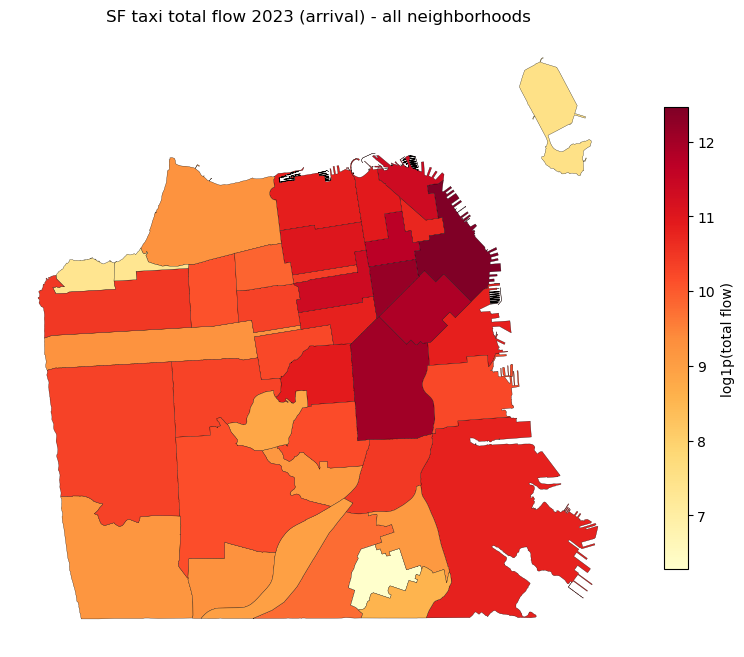

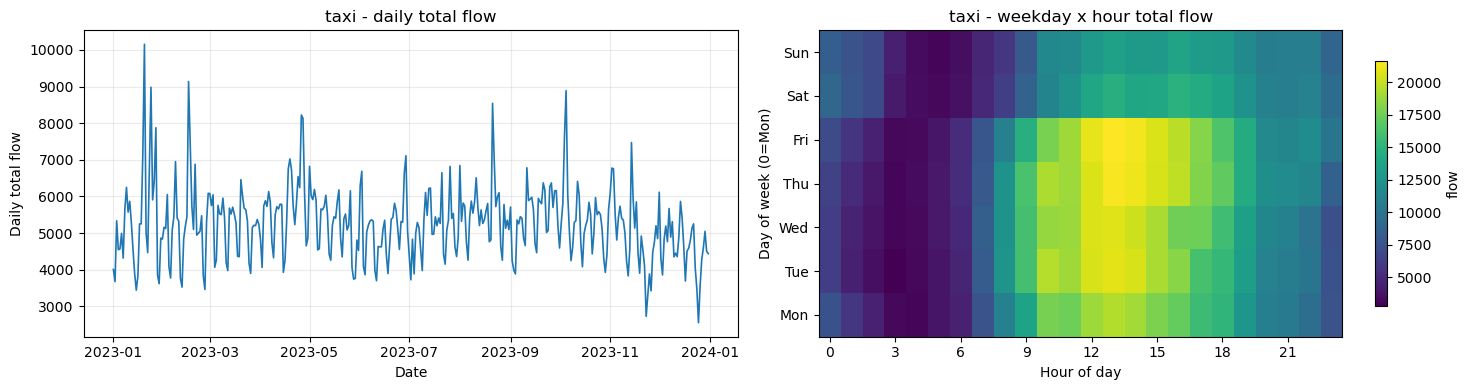

=== Sparsity report: bike ===
  shape=(41, 35040), total_flow=2,334,347
  nnz cells=553,532/1,436,640  zero_rate=61.470%
  dead regions=2/41  dead steps=342/35040
  region totals  min/Q1/med/Q3/max = 0 / 2,892 / 28,765 / 53,577 / 433,865
  step totals    min/Q1/med/Q3/max = 0 / 14 / 57 / 102 / 333
  step totals  (non-zero only) Q1/med/Q3 = 15 / 58 / 102
  first_active=2023-01-01 00:00:00, last_active=2023-12-31 23:45:00


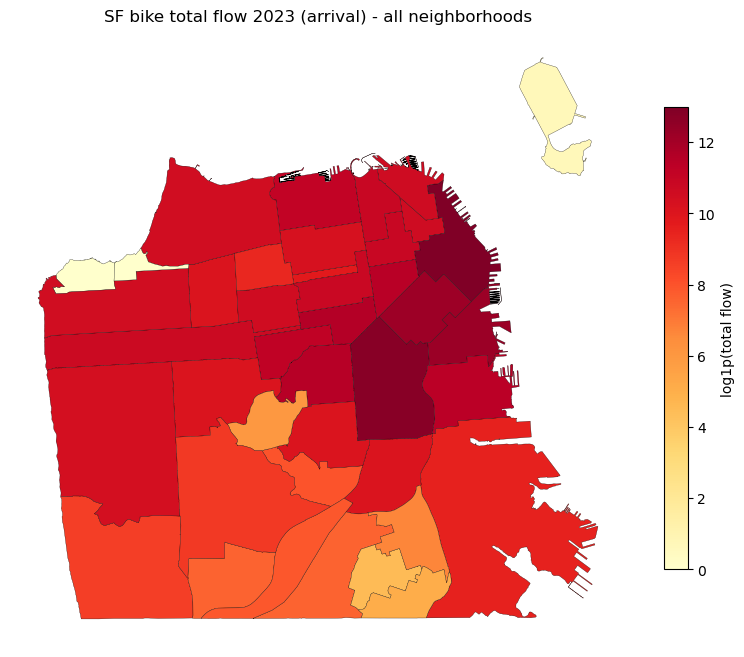

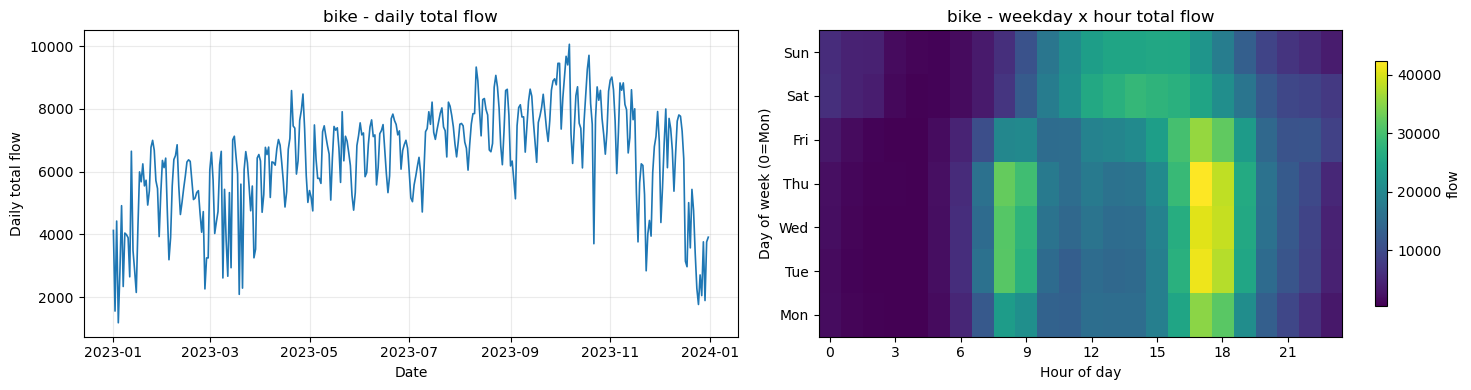

In [43]:
nhood_active = TARGET_NHOODS is not None and (not isinstance(TARGET_NHOODS, str) or TARGET_NHOODS.lower() != "all")
for name, arr, time_index in MOBILITY_VIZ:
    sparsity_report(name, arr, time_index)
    plot_nhood_heat(nhoods, arr.sum(axis=1), f"SF {name} total flow {YEAR} ({FLOW_MODE}) - all neighborhoods")
    if nhood_active:
        sub = arr[sel_idx]
        sparsity_report(f"{name} [{TARGET_TAG}]", sub, time_index)
        plot_nhood_heat(nhoods_sel, sub.sum(axis=1), f"SF {name} total flow {YEAR} ({FLOW_MODE}) - {TARGET_TAG}")
    plot_temporal_panels(name, arr, time_index)

## Generate dataset (NDT)

Reorder the merged `(N, M, T)` tensor to `(N, D, T)` and feed it to
`utils/generate.py` with `--fmt NDT --clip_neg --per_channel --log1p`, producing
the `sf_15min` dataset across the standard horizon suite (12to1 ... 12to12).

In [44]:
if TARGET_NHOODS is not None and (not isinstance(TARGET_NHOODS, str) or TARGET_NHOODS.lower() != "all"):
    src_path = OUT_DIR / f"sf_{nhood_tag}_{merged_tag}_{YEAR}_{FREQ_TAG}.npy"
    DATASET = f"sf_{nhood_tag}_15min"
else:
    src_path = OUT_DIR / f"sf_{merged_tag}_{YEAR}_{FREQ_TAG}.npy"
    DATASET = "sf_15min"

merged_arr = np.load(src_path)
M = len(MERGE_MOBILITIES)
if merged_arr.shape[0] == M and merged_arr.shape[1] != M:
    ndt = merged_arr.transpose(1, 0, 2)   # (M, N, T) -> (N, D, T)
elif merged_arr.shape[1] == M:
    ndt = merged_arr                       # already (N, D, T)
else:
    raise ValueError(f"Cannot locate mobility axis (M={M}) in {merged_arr.shape}")
ndt_path = src_path.with_name(src_path.stem + "_NDT.npy")
np.save(ndt_path, ndt)
print(f"{ndt_path} shape={tuple(ndt.shape)} (N, D, T) with D={M} mobilities")


YEAR = 2025 # For convience
for hy in [1, 3, 6, 9, 12]:
    subprocess.run([
        "python3", "/home/dy23a.fsu/st/utils/generate.py",
        "--data_path", str(ndt_path),
        "--fmt", "NDT",
        "--clip_neg",
        "--per_channel",
        "--log1p",
        "--dataset", DATASET,
        "--years", f"{YEAR}_12to{hy}",
        "--seq_length_x", "12",
        "--seq_length_y", str(hy),
    ], check=True)

/home/dy23a.fsu/st/datasets/raw/SF/sf_taxi_bike_2023_15min_NDT.npy shape=(41, 2, 35040) (N, D, T) with D=2 mobilities


Loaded /home/dy23a.fsu/st/datasets/raw/SF/sf_taxi_bike_2023_15min_NDT.npy, raw shape: (41, 2, 35040)
Clipped negative values to 0
Reordered NDT → TND, shape: (35040, 41, 2)
Raw — max: 181, min: 0, mean: 1.4805, std: 3.4241
Index range: [11, 35039), total=35028, train=28022, val=3503, test=3503
MinMaxScaler(log1p=True) min: [0.0, 0.0], max: [5.204006671905518, 5.0434250831604]
Normalized — max: 1.0000, min: 0.0000, mean: 0.1045, std: 0.1446
Saved meta.json to /blue/gtyson.fsu/dy23a.fsu/datasets/sf_15min/2025_12to1/meta.json
Saved to /blue/gtyson.fsu/dy23a.fsu/datasets/sf_15min/2025_12to1
Saved info.json to /blue/gtyson.fsu/dy23a.fsu/datasets/sf_15min/2025_12to1/info.json
Loaded /home/dy23a.fsu/st/datasets/raw/SF/sf_taxi_bike_2023_15min_NDT.npy, raw shape: (41, 2, 35040)
Clipped negative values to 0
Reordered NDT → TND, shape: (35040, 41, 2)
Raw — max: 181, min: 0, mean: 1.4805, std: 3.4241
Index range: [11, 35037), total=35026, train=28020, val=3503, test=3503
MinMaxScaler(log1p=True) m

## Adjacency

Distance-based adjacency over the selected neighborhood centroids, saved
alongside the dataset. Centroids are computed in a projected CRS (EPSG:3310,
California Albers, meters) to avoid the geographic-CRS centroid warning.

In [45]:
sys.path.insert(0, "/home/dy23a.fsu/st/utils")
from get_adj_mat import get_adjacency_matrix

ADJ_DIR = Path("/home/dy23a.fsu/st/datasets") / DATASET
ADJ_DIR.mkdir(parents=True, exist_ok=True)
ADJ_OUT = ADJ_DIR / "sf.npy"
adj_gdf = nhoods_sel if nhood_active else nhoods

ctr = adj_gdf.set_geometry("geometry").to_crs("EPSG:3310").centroid.reset_index(drop=True)
N_adj = len(ctr)
ids = list(range(N_adj))
distance = [[i, j, ctr[i].distance(ctr[j])] for i in ids for j in ids]
adj_mx = get_adjacency_matrix(distance_df=distance, sensor_ids=ids)
np.save(ADJ_OUT, adj_mx)
print(f"Saved {ADJ_OUT} shape={adj_mx.shape}")

Saved /home/dy23a.fsu/st/datasets/sf_15min/sf.npy shape=(41, 41)
